# Практическое занятие 7. Анализ синтетических сигналов частичных разрядов

Версия: преподавательская.

Цель занятия - показать полный переход от временного сигнала к
признакам и простой классификационной модели. Частичный разряд
(partial discharge, PD) - локальный электрический пробой малой
части изоляции, который не замыкает электроды полностью, но
является важным диагностическим признаком старения изоляции.

## Инициализация среды выполнения

Ячейка ниже обеспечивает запуск блокнота в Google Colab и в
локальном Jupyter Notebook. Если проект уже открыт локально,
повторное клонирование не выполняется.

In [1]:
# COLAB_BOOTSTRAP_APPailab
from pathlib import Path
import os
import sys

REQUIRED_PROCESSED_FILES = ['practice_07_pd_signal_features.csv', 'practice_07_pd_signal_diagnostics.csv', 'practice_07_pd_signal_waveforms.csv', 'practice_07_09_dataset_catalog.csv', 'practice_07_09_dataset_assignments.csv']
PROJECT_REPOSITORY_URL = "https://github.com/Alexflex/appailab.git"

def find_project_root(start: Path) -> Path | None:
    for candidate in [start, *start.parents]:
        if (candidate / "requirements-colab.txt").exists() and (candidate / "data" / "processed").exists():
            return candidate
    return None

project_root = find_project_root(Path.cwd())

if project_root is None:
    try:
        import google.colab  # type: ignore
        IN_COLAB = True
    except Exception:
        IN_COLAB = False

    if IN_COLAB:
        workdir = Path("/content/appailab")
        if not workdir.exists():
            !git clone -q {PROJECT_REPOSITORY_URL} {workdir}
        project_root = workdir
        os.chdir(project_root)
        !pip install -q -r requirements-colab.txt
    else:
        raise FileNotFoundError(
            "Не найден корень проекта. Откройте блокнот из репозитория appailab "
            "или выполните git clone перед запуском."
        )

sys.path.insert(0, str(project_root / "src"))
missing_files = [
    name for name in REQUIRED_PROCESSED_FILES
    if not (project_root / "data" / "processed" / name).exists()
]
if missing_files:
    raise FileNotFoundError(
        "Не найдены подготовленные CSV: " + ", ".join(missing_files)
        + ". Выполните python scripts/generate_datasets.py."
    )

print(f"Корень проекта: {project_root}")
print("Проверенные CSV:", ", ".join(REQUIRED_PROCESSED_FILES))

Корень проекта: /mnt/f/projects/appai_lab
Проверенные CSV: practice_07_pd_signal_features.csv, practice_07_pd_signal_diagnostics.csv, practice_07_pd_signal_waveforms.csv, practice_07_09_dataset_catalog.csv, practice_07_09_dataset_assignments.csv


In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import GradientBoostingRegressor, RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

DATA_DIR = project_root / "data" / "processed"
CATALOG_07_09_FILE = DATA_DIR / "practice_07_09_dataset_catalog.csv"
ASSIGNMENTS_07_09_FILE = DATA_DIR / "practice_07_09_dataset_assignments.csv"
RANDOM_STATE = 20260507

## Теоретический блок

Временная область описывает изменение напряжения `x(t)` во времени.
Частотная область описывает, на каких частотах сосредоточена энергия
сигнала. Быстрое преобразование Фурье (Fast Fourier Transform, FFT)
является алгоритмом вычисления дискретного спектра.

Энергия дискретного сигнала оценивается как

$$
E = \sum_{i=1}^{N} x_i^2 \Delta t,
$$

где `x_i` - отсчет сигнала, `Delta t` - шаг дискретизации. Отношение
сигнал-шум (Signal-to-Noise Ratio, SNR) показывает, насколько
полезный сигнал превышает уровень шума.

## Последовательность работы

1. Загрузить таблицу признаков, diagnostics-CSV и временные отсчеты.
2. Построить временные графики для нескольких классов состояния.
3. Построить амплитудные спектры и сравнить доминирующие частоты.
4. Выбрать безопасные признаки без прямой диагностической разметки.
5. Обучить классификатор и проанализировать матрицу ошибок.
6. Разобрать антипример утечки данных.

In [3]:
features_df = pd.read_csv(DATA_DIR / "practice_07_pd_signal_features.csv")
diagnostics_df = pd.read_csv(DATA_DIR / "practice_07_pd_signal_diagnostics.csv")
waveforms_df = pd.read_csv(DATA_DIR / "practice_07_pd_signal_waveforms.csv")

print("features:", features_df.shape)
print("diagnostics:", diagnostics_df.shape)
print("waveforms:", waveforms_df.shape)
display(features_df.head())

features: (400, 12)
diagnostics: (400, 8)
waveforms: (51200, 6)


,sample_id,profile_id,sampling_rate_hz,window_duration_us,max_abs_voltage_v,rms_voltage_v,signal_energy,pulse_count_est,dominant_freq_khz,spectral_centroid_khz,snr_db,condition_class
0,1,8,2000000.0,64.0,0.56205,0.08359,4.472000e-07,11,31.250,358.366,11.283,rare_pd
1,2,4,2000000.0,64.0,0.73827,0.21177,2.870300e-06,46,31.250,310.745,18.152,frequent_pd
2,3,1,2000000.0,64.0,0.67270,0.12215,9.549000e-07,6,31.250,363.027,4.975,noisy
3,4,7,2000000.0,64.0,0.21321,0.11215,8.049000e-07,47,234.375,369.255,11.131,external_interference
4,5,5,2000000.0,64.0,0.52291,0.07009,3.144000e-07,6,15.625,359.081,9.614,rare_pd


## Паспорт данных

Одна строка feature-CSV соответствует одному окну сигнала. Одна
строка waveforms-CSV соответствует одному отсчету одного окна. Целевая
переменная `condition_class` задает учебное состояние: нормальный
сигнал, редкие разряды, частые разряды, шумовой режим или внешняя
помеха.

In [4]:
display(features_df.groupby("condition_class").agg(
    n=("sample_id", "count"),
    mean_energy=("signal_energy", "mean"),
    mean_snr=("snr_db", "mean"),
    mean_pulses=("pulse_count_est", "mean"),
).round(4))

,n,mean_energy,mean_snr,mean_pulses
condition_class,,,,
external_interference,80,0.0,11.6724,54.3000
frequent_pd,80,0.0,16.4738,33.5875
noisy,80,0.0,-44.3435,1.5625
normal,80,0.0,-20.3901,0.0000
rare_pd,80,0.0,11.0074,12.0250


## Временные сигналы

На графиках ниже видно, что амплитуда сама по себе не всегда
достаточна: шумовой режим может иметь заметную амплитуду, но не
содержать устойчивой импульсной структуры.

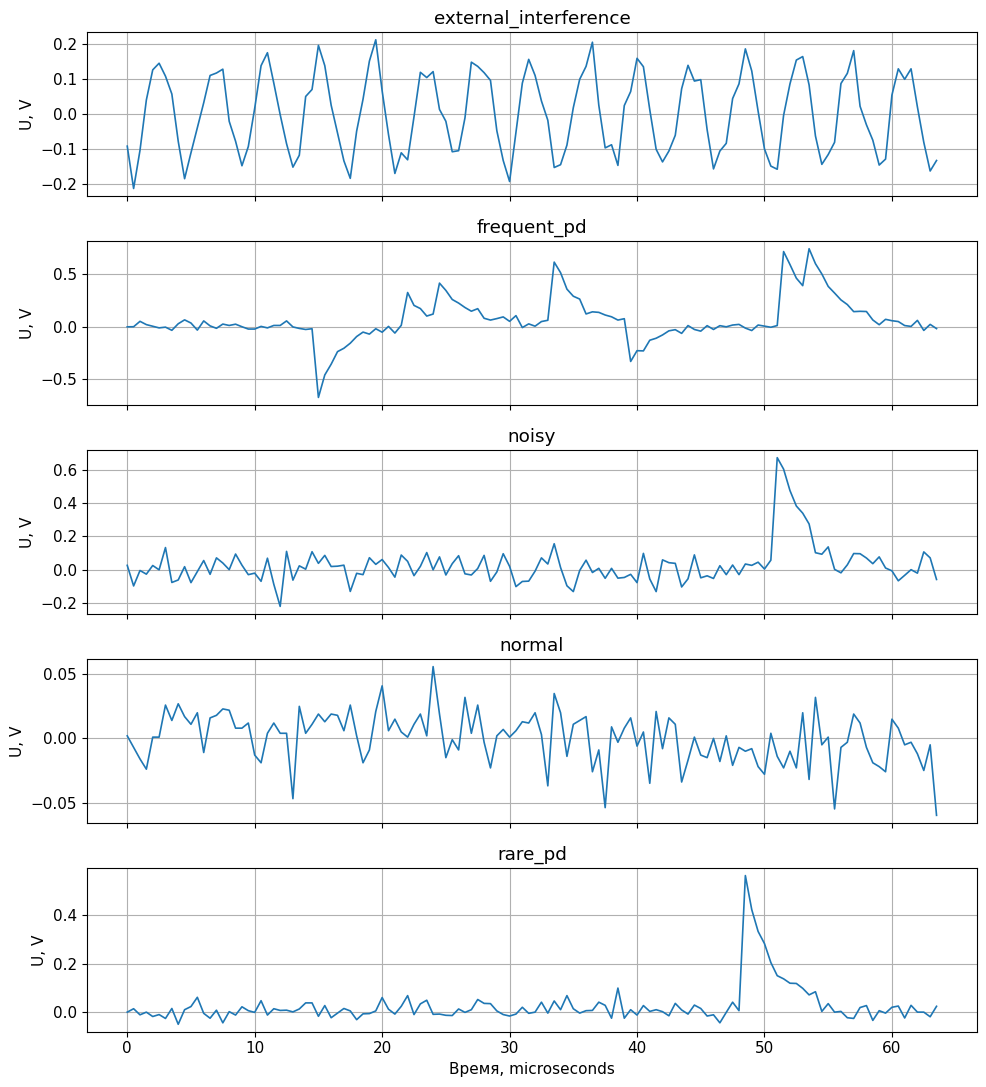

In [5]:
example_ids = (
    features_df.groupby("condition_class")["sample_id"]
    .first()
    .to_dict()
)
fig, axes = plt.subplots(len(example_ids), 1, figsize=(10, 11), sharex=True)
for ax, (label, sample_id) in zip(axes, example_ids.items()):
    part = waveforms_df[waveforms_df["sample_id"] == sample_id]
    ax.plot(part["time_us"], part["voltage_v"], linewidth=1.2)
    ax.set_title(label)
    ax.set_ylabel("U, V")
axes[-1].set_xlabel("Время, microseconds")
plt.tight_layout()
plt.show()

## Спектральный анализ

Спектр помогает отделить импульсные события от гармонической внешней
помехи. Внешняя помеха может иметь выраженный частотный пик, тогда
как импульсный разряд распределяет энергию шире.

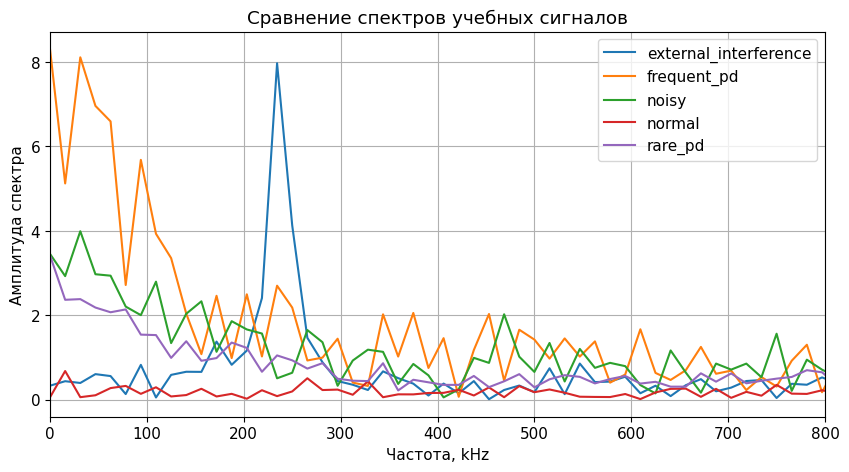

In [6]:
def plot_spectrum(sample_id: int, label: str) -> None:
    part = waveforms_df[waveforms_df["sample_id"] == sample_id].sort_values("point_index")
    signal = part["voltage_v"].to_numpy()
    dt = (part["time_us"].iloc[1] - part["time_us"].iloc[0]) * 1e-6
    freq_khz = np.fft.rfftfreq(len(signal), d=dt) / 1000.0
    spectrum = np.abs(np.fft.rfft(signal))
    plt.plot(freq_khz, spectrum, label=label)

plt.figure(figsize=(10, 5))
for label, sample_id in example_ids.items():
    plot_spectrum(sample_id, label)
plt.xlim(0, 800)
plt.xlabel("Частота, kHz")
plt.ylabel("Амплитуда спектра")
plt.title("Сравнение спектров учебных сигналов")
plt.legend()
plt.show()

## Выбор признаков

Безопасные признаки - это величины, которые можно рассчитать из
сигнала до знания целевого класса. Диагностические столбцы
`state_code`, `direct_state_label` и `leakage_pd_indicator` не
включаются в базовую модель.

In [7]:
signal_features = ['max_abs_voltage_v', 'rms_voltage_v', 'signal_energy', 'pulse_count_est', 'dominant_freq_khz', 'spectral_centroid_khz', 'snr_db']

forbidden_signal_features = {'state_code', 'direct_state_label', 'leakage_pd_indicator'}
leaked = forbidden_signal_features & set(signal_features)
if leaked:
    raise ValueError(f'Обнаружена утечка данных: {sorted(leaked)}')

In [8]:
max_iter = 160

## Базовая классификационная модель

Логистическая регрессия (Logistic Regression) оценивает вероятность
класса через линейную комбинацию признаков. Масштабирование
необходимо, потому что энергия, частота и напряжение имеют разные
единицы измерения.

In [9]:
X = features_df[signal_features]
y = features_df["condition_class"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

pd_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=max_iter, class_weight="balanced")),
])
pd_model.fit(X_train, y_train)
y_pred = pd_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Macro-F1:", round(f1_score(y_test, y_pred, average="macro"), 4))
print(classification_report(y_test, y_pred))

Accuracy: 0.98
Macro-F1: 0.9799
                       precision    recall  f1-score   support

external_interference       1.00      1.00      1.00        20
          frequent_pd       0.91      1.00      0.95        20
                noisy       1.00      0.90      0.95        20
               normal       1.00      1.00      1.00        20
              rare_pd       1.00      1.00      1.00        20

             accuracy                           0.98       100
            macro avg       0.98      0.98      0.98       100
         weighted avg       0.98      0.98      0.98       100



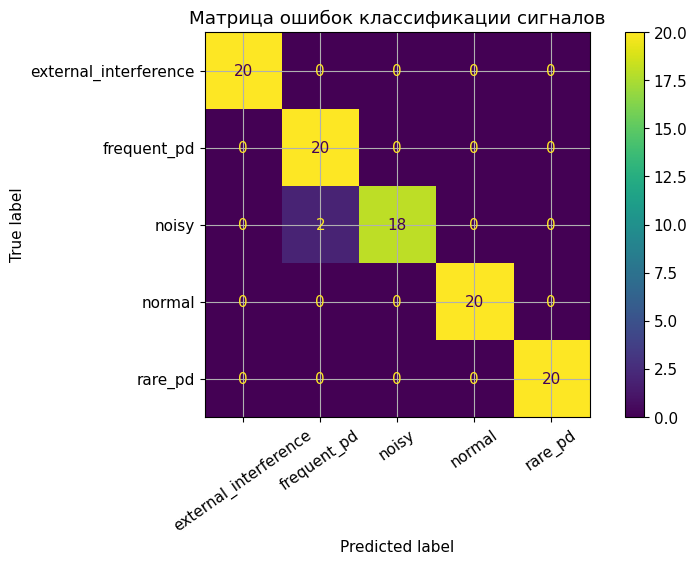

In [10]:
cm = confusion_matrix(y_test, y_pred, labels=pd_model.classes_)
ConfusionMatrixDisplay(cm, display_labels=pd_model.classes_).plot(xticks_rotation=35)
plt.title("Матрица ошибок классификации сигналов")
plt.show()

## Сравнение с ансамблевой моделью

Случайный лес (Random Forest) строит множество деревьев решений и
усредняет их ответы. Для начального уровня важно не стремиться к
максимальной сложности, а сравнить качество и интерпретируемость.

In [11]:
forest_model = RandomForestClassifier(
    n_estimators=160,
    max_depth=6,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    class_weight="balanced",
)
forest_model.fit(X_train, y_train)
forest_pred = forest_model.predict(X_test)
model_summary = pd.DataFrame([
    {
        "model": "LogisticRegression",
        "accuracy": accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro"),
    },
    {
        "model": "RandomForestClassifier",
        "accuracy": accuracy_score(y_test, forest_pred),
        "macro_f1": f1_score(y_test, forest_pred, average="macro"),
    },
])
display(model_summary.round(4))

,model,accuracy,macro_f1
0,LogisticRegression,0.98,0.9799
1,RandomForestClassifier,0.97,0.9700


## АНТИПРИМЕР: утечка диагностической разметки

Блок ниже показывает запрещенный прием. Если присоединить
`state_code` из diagnostics-CSV, модель получает почти прямое
числовое представление ответа. Такой результат нельзя использовать
в отчете как качество диагностической модели.

In [12]:
leakage_df = features_df.merge(diagnostics_df, on="sample_id", validate="one_to_one")
leakage_features = signal_features + ["state_code"]
X_leak = leakage_df[leakage_features]
y_leak = leakage_df["condition_class"]
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_leak, y_leak, test_size=0.25, random_state=RANDOM_STATE, stratify=y_leak
)
leakage_model = RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced")
leakage_model.fit(X_train_l, y_train_l)
leakage_pred = leakage_model.predict(X_test_l)
print("Запрещенный результат с утечкой, Macro-F1:", round(f1_score(y_test_l, leakage_pred, average="macro"), 4))

Запрещенный результат с утечкой, Macro-F1: 1.0


In [13]:
signal_interpretation = 'Энергия и число импульсных превышений лучше отделяют частые разряды от нормального режима, но внешняя помеха требует анализа спектра.'
print(signal_interpretation)

Энергия и число импульсных превышений лучше отделяют частые разряды от нормального режима, но внешняя помеха требует анализа спектра.


## Источники и проверка актуальности

Базовые занятия 7-9 используют локальные воспроизводимые CSV. Открытые
источники ниже применяются как методические задания: студент должен
определить объект, признаки, целевую переменную, риски утечки данных
и допустимые визуализации.

In [14]:
catalog_07_09 = pd.read_csv(CATALOG_07_09_FILE)
assignments_07_09 = pd.read_csv(ASSIGNMENTS_07_09_FILE)
display(catalog_07_09[[
    "dataset_id", "name", "lessons", "implementation_status",
    "risk_level", "checked_at"
]])

,dataset_id,name,lessons,implementation_status,risk_level,checked_at
0,mendeley_pd_cables_toa,Partial Discharge Signals in Insulated Power C...,7,methodology_only,средний,2026-05-16
1,zenodo_pd_calibrator,Dataset for New Synthetic Partial Discharge Ca...,7,methodology_only,низкий,2026-05-16
2,pandapower_case9,pandapower IEEE 9-bus example network,"8,9",methodology_only,низкий,2026-05-16
3,ieee_pes_test_feeders,IEEE PES Distribution Test Feeders,"8,9",methodology_only,средний,2026-05-16
4,matpower_cases,MATPOWER case archive,"8,9",methodology_only,средний,2026-05-16


## Реестр найденных наборов данных и развернутые задания

Все источники имеют статус `methodology_only`, то есть на данном
этапе они не являются обязательными для выполнения в аудитории.

In [15]:
display(assignments_07_09[[
    "assignment_id", "lesson", "assignment_title",
    "recommended_visualizations", "control_questions"
]])

,assignment_id,lesson,assignment_title,recommended_visualizations,control_questions
0,mendeley_pd_cables_toa_lesson_7,7,Извлечение признаков из сигналов: Partial Disc...,временной сигнал; спектр; таблица признаков; м...,Почему шаг дискретизации входит в расчет энерг...
1,zenodo_pd_calibrator_lesson_7,7,Извлечение признаков из сигналов: Dataset for ...,временной сигнал; спектр; таблица признаков; м...,Почему шаг дискретизации входит в расчет энерг...
2,pandapower_case9_lesson_8,8,Расчет режима по открытой тестовой сети: panda...,таблица напряжений; диаграмма загрузки линий; ...,Что является входом расчета? Почему расчет реж...
3,pandapower_case9_lesson_9,9,Сравнение AC/DC и суррогатной модели: pandapow...,AC против DC; распределение ошибок; график про...,Когда DC-приближение допустимо? Почему AC-резу...
4,ieee_pes_test_feeders_lesson_8,8,Расчет режима по открытой тестовой сети: IEEE ...,таблица напряжений; диаграмма загрузки линий; ...,Что является входом расчета? Почему расчет реж...
5,ieee_pes_test_feeders_lesson_9,9,Сравнение AC/DC и суррогатной модели: IEEE PES...,AC против DC; распределение ошибок; график про...,Когда DC-приближение допустимо? Почему AC-резу...
6,matpower_cases_lesson_8,8,Расчет режима по открытой тестовой сети: MATPO...,таблица напряжений; диаграмма загрузки линий; ...,Что является входом расчета? Почему расчет реж...
7,matpower_cases_lesson_9,9,Сравнение AC/DC и суррогатной модели: MATPOWER...,AC против DC; распределение ошибок; график про...,Когда DC-приближение допустимо? Почему AC-резу...


## Контрольный чек-лист отчета

1. Указаны частота дискретизации и длительность окна.
2. Построены временные графики и спектры.
3. Объяснены амплитуда, энергия, SNR и доминирующая частота.
4. Диагностические столбцы не использованы как признаки.
5. Приведены метрики классификации и инженерный вывод.